#  Análisis: k - Nearest Neighbor Rule

En el presente documento, se realizara el análisis a priori y a posteriori del alogritmo de clasificación `k- Nearest Neighbors`.



# Análisis A priori de la función `kNN_algorithm`

Con base a al definición de la función `kNN_algorithm`, se analizara para obtener su compllejidad en tiempo. Recordemos que:
- Big $O$, corresponde al peor caso
- $\Omega$, corresponde al mejor caso (caso base)
- $\Theta$, corresponde al caso general cuando no hay una diferencica entre el mejor y el pero caso


A continuación, se muestra el código de la función y como comentario se agrega su costo.


```python

def euclidean_distance(pointA: array, pointB: array) -> float:
    res = 0
    # Un punto contiene 2 elementos (x, y)
    # Recorremos siempre 2 elementos  -> O(2)
    for i in range(len(pointA) - 1):
        res += (pointB[i] - pointA[i])**2
    return sqrt(res)

def sort_kNeighbors(kNeibors: list, new_class: str, new_distance: float, k: int) -> None:
    new_dist = (new_distance, new_class) # O(1)
    kNeibors.append(new_dist) # O(1)
    kNeibors.sort() # O(k log k) -> obtenido de la documentación
    if len(kNeibors) > k: # O(1)
        while len(kNeibors) > k: 
            kNeibors.pop() # O(1)

def kNN_algorithm(k: int, new_value: list) -> tuple[int, Optional[str]]:

    # O(1)
    kNeighbors = []

    # O(1)
    dataset: array = df.iloc[:,:].values
    
    # O(n * res)
    for i, row in enumerate(dataset):
        curr_distance: float = euclidean_distance(row, new_value). # O(2) 
        sort_kNeighbors(kNeighbors, row[-1], curr_distance, k) # O(k log k)
    
    # checkpoint -> O(n * k log k) 
    
    votes: dict = {
        "Iris-setosa": 0, 
        "Iris-versicolor": 0, 
        "Iris-virginica": 0
    }

    max_curr = (0, None)
    # O(k)
    for elem in kNeighbors:
        if elem[1] == "Iris-setosa": # complejidad constante
            votes["Iris-setosa"] += 1
            if max_curr[0] <= votes["Iris-setosa"]:
                max_curr = (votes["Iris-setosa"], "Iris-setosa")
        elif elem[1] == "Iris-versicolor": # complejidad constante
            votes["Iris-versicolor"] += 1
            if max_curr[0] <= votes["Iris-versicolor"]:
                max_curr = (votes["Iris-versicolor"], "Iris-versicolor")
        elif elem[1] == "Iris-virginica": # complejidad constante
            votes["Iris-virginica"] += 1
            if max_curr[0] <= votes["Iris-virginica"]:
                max_curr = (votes["Iris-virginica"], "Iris-virginica")
        else:
            raise ValueError(f"Class {elem[1][-1]} has not been defined")
    
    return max_curr
```

Como resultado tenemos que $O(n * k * log(k)) + O(k)$, sin embargo, dado que $O(n * k * log(k)) > O(k)$, la complejidad es $O(n * k * log(k))$. En resumen, el algoritmo varia en función de `k`, debido a la función `.sort()` que en el mejor caso global es cuando `k = 1` y el ordenamiento de los `k` elementos practicamente es $O(1)$ y por lo tanto, $\Omega(n)$ porque predomina el ciclo externo. En el caso, del peor caso tenemos que si `k`es grande, cada una das la `n` iteraciones ejecuta `.sort()` sobre a lo mas `k + 1` elementos, eso quiere decir que tendríamos $O(k*log(k))$ por iteración, `n`veces.

- Mejor caso: $\Omega(n)$
- Peor caso: $O(n * k * log(k))$

Para este caso no tenemos $\Theta$ dado que la complejidad esta en función de `k`, si `k` fuera constante en todos los casos entonces la complejidad colapsaría a $\Theta(n)$



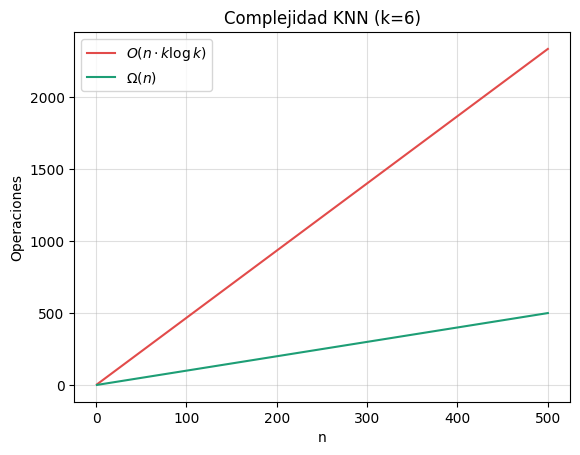

In [11]:
import numpy as np
import matplotlib.pyplot as plt

N = np.arange(1, 501)
k = 6

plt.plot(N, N * k * np.log10(k), color="#E24B4A", label=r"$O(n \cdot k \log k)$")
plt.plot(N, N, color="#1D9E75", label=r"$\Omega(n)$")

plt.title(f"Complejidad KNN (k={k})")
plt.xlabel("n"); plt.ylabel("Operaciones")
plt.legend(); plt.grid(alpha=0.4)
plt.show()

# Análisis A posteriori de la función `kNN_algorithm`

Para el análisis a posteriori, utilizaremos como conjuntos de datos de prueba el dataset "Iris". Deberiamos de obtener una gráfica similar a la anterior.

In [12]:
import pandas as pd

df = pd.read_csv('iris/iris.data', header=None)

# Mostramos las columnas del DataFrame
print(df.columns)

# Asignamos nombres a las columnas
df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

Index([0, 1, 2, 3, 4], dtype='int64')


## Implementación

La idea de k-NN, es comparar la distancia entre cada uno de los registros con la entrada `t` y guardar los `k` registros más cercanos a `t`. La clase que tenga el mayor número de vecinos dentro de los `k` vecinos encontrados, determina la clase del nuevo elemento.

Con esta idea en mente, se implementaría un `k-NN` con lazy learning

In [13]:
from math import sqrt
from typing import Optional
from numpy import array


def euclidean_distance(pointA: array, pointB: array) -> float:
    """
    Calculate the euclidena distnace between A and B
    """
    res = 0
    for i in range(len(pointA) - 1):
        res += (pointB[i] - pointA[i])**2
    return sqrt(res)

def sort_kNeighbors(kNeibors: list, new_class: str, new_distance: float, k: int) -> None:
    """
    Will update the list to keep sort it with the following format
    [[new_value, new_distance], ..., [k-new_value, k-new_distance]]
    """
    new_dist = (new_distance, new_class)
    kNeibors.append(new_dist)
    kNeibors.sort() # O(m log m)
    if len(kNeibors) > k:
        while len(kNeibors) > k:
            kNeibors.pop()

def kNN_algorithm(k: int, new_value: list) -> tuple[int, Optional[str]]:
    """
    Gets the classification of the new_value by comparing the euclidean distance, and
    determine its classification based on k elements that are near the new_value
    """
    global df 
    kNeighbors = []

    dataset: array = df.iloc[:,:].values # [sepal_length, sepal_width, petal_length, petal_width, class] - Numpy array

    for i, row in enumerate(dataset):
        curr_distance: float = euclidean_distance(row, new_value)
        sort_kNeighbors(kNeighbors, row[-1], curr_distance, k)
    
    votes: dict = {
        "Iris-setosa": 0, 
        "Iris-versicolor": 0, 
        "Iris-virginica": 0
    }

    max_curr = (0, None)
    for elem in kNeighbors:
        if elem[1] == "Iris-setosa":
            votes["Iris-setosa"] += 1
            if max_curr[0] <= votes["Iris-setosa"]:
                max_curr = (votes["Iris-setosa"], "Iris-setosa")
        elif elem[1] == "Iris-versicolor":
            votes["Iris-versicolor"] += 1
            if max_curr[0] <= votes["Iris-versicolor"]:
                max_curr = (votes["Iris-versicolor"], "Iris-versicolor")
        elif elem[1] == "Iris-virginica":
            votes["Iris-virginica"] += 1
            if max_curr[0] <= votes["Iris-virginica"]:
                max_curr = (votes["Iris-virginica"], "Iris-virginica")
        else:
            raise ValueError(f"Class {elem[1][-1]} has not been defined")
    
    return max_curr

example = [5.0, 3.6, 1.4, 0.2, None]
k = 3
print(kNN_algorithm(k, example))



(3, 'Iris-setosa')


     n    k    Tiempo (ms)                Ratio
--------------------------------------------------
    10    3         0.0405           0.00085146
    25    5         0.0501           0.00017246
    50    7         0.0524           0.00005333
    75    9         0.0695           0.00003250
   100   11         0.0819           0.00002152
   150   15         0.1295           0.00001473


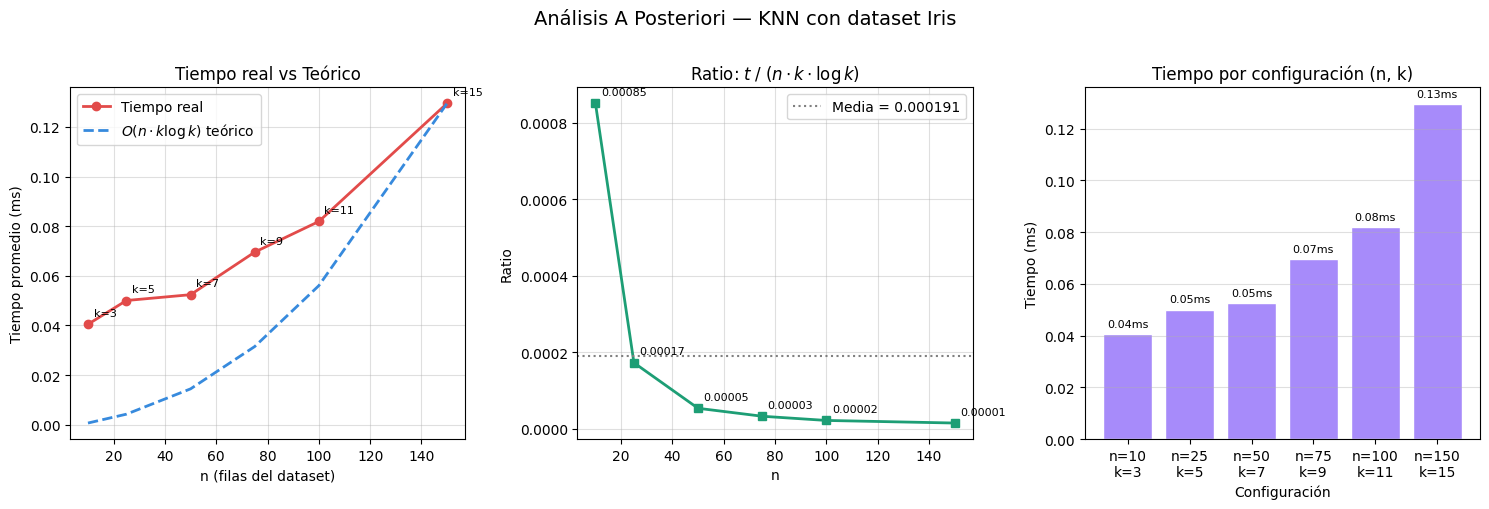


Gráfica guardada como knn_aposteriori_iris.png


In [ ]:
import time

sizes    = [10, 25, 50, 75, 100, 150]   # segmentos del dataset
k_values = [ 3,  5,  7,  9,  11,  15]  # k ≈ sqrt(n), siempre impar
REPS     = 30                           # repeticiones para estabilizar el promedio

full_df = df
new_value = list(full_df.iloc[0, :4].astype(float)) + [0]   # punto de consulta fijo (primera fila)

results = []
print(f"{'n':>6} {'k':>4} {'Tiempo (ms)':>14} {'Ratio':>20}")
print("-" * 50)

for n, k in zip(sizes, k_values):
    df = full_df.iloc[:n].copy() # segmento del dataset
    times = []

    for _ in range(REPS):
        start = time.perf_counter()
        kNN_algorithm(k, new_value)
        end   = time.perf_counter()
        times.append((end - start) * 1000)

    avg  = np.mean(times)
    ratio = avg / (n * k * np.log2(k))
    results.append((n, k, avg, ratio))
    print(f"{n:>6} {k:>4} {avg:>14.4f} {ratio:>20.8f}")

# ------------------------------------------------------------------ #
#  GRÁFICAS                                                          #
# ------------------------------------------------------------------ #
ns     = [r[0] for r in results]
ks     = [r[1] for r in results]
times  = [r[2] for r in results]
ratios = [r[3] for r in results]

scale       = times[-1] / (ns[-1] * ks[-1] * np.log2(ks[-1]))
theoretical = [n * k * np.log2(k) * scale for n, k in zip(ns, ks)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Análisis A Posteriori — KNN con dataset Iris", fontsize=14, y=1.01)

# 1. Tiempo real vs teórico
axes[0].plot(ns, times,"o-", color="#E24B4A", linewidth=2, label="Tiempo real")
axes[0].plot(ns, theoretical, "--", color="#378ADD", linewidth=2, label=r"$O(n \cdot k \log k)$ teórico")
for n, k, t in zip(ns, ks, times):
    axes[0].annotate(f"k={k}", (n, t), textcoords="offset points", xytext=(4, 6), fontsize=8)
axes[0].set_title("Tiempo real vs Teórico")
axes[0].set_xlabel("n (filas del dataset)")
axes[0].set_ylabel("Tiempo promedio (ms)")
axes[0].legend(); axes[0].grid(alpha=0.4)

# 2. Ratio t / (n·k·log k) — debe ser constante
axes[1].plot(ns, ratios, "s-", color="#1D9E75", linewidth=2)
axes[1].axhline(np.mean(ratios), color="gray", linestyle=":",
                linewidth=1.5, label=f"Media = {np.mean(ratios):.6f}")
for n, r in zip(ns, ratios):
    axes[1].annotate(f"{r:.5f}", (n, r), textcoords="offset points", xytext=(4, 6), fontsize=8)
axes[1].set_title(r"Ratio: $t \;/\; (n \cdot k \cdot \log k)$")
axes[1].set_xlabel("n"); axes[1].set_ylabel("Ratio")
axes[1].legend(); axes[1].grid(alpha=0.4)

# 3. Barras por configuración
labels = [f"n={n}\nk={k}" for n, k in zip(ns, ks)]
bars   = axes[2].bar(labels, times, color="#A78BFA", edgecolor="white")
axes[2].bar_label(bars, labels=[f"{t:.2f}ms" for t in times], padding=4, fontsize=8)
axes[2].set_title("Tiempo por configuración (n, k)")
axes[2].set_xlabel("Configuración"); axes[2].set_ylabel("Tiempo (ms)")
axes[2].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("IMG/knn_aposteriori_iris.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGráfica guardada como knn_aposteriori_iris.png")